# Layout Pareto Analysis
This notebook defines the standalone layout solver and renders Pareto-frontier plots for the selected mixed-precision cases. It shows feasible layout candidates, prefilling and decoding frontiers, and the multi-panel Pareto summary used for layout analysis.


In [1]:
# Purpose: Import numerical, optimization, and plotting dependencies.
import json
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import sparse
from scipy.optimize import minimize, linprog, milp, Bounds, LinearConstraint
import functools

try:
    from adjustText import adjust_text
except ModuleNotFoundError:
    def adjust_text(*_args, **_kwargs):
        """Use a no-op fallback when adjustText is unavailable."""
        return []


plt.rcParams["font.family"] = (
    "serif" 
)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]
mpl.rcParams['hatch.linewidth'] = 1


In [2]:
# Purpose: Define a reusable color-gradient helper for plotting utilities.
def color_gradient(c1, c2, steps, use_hsv=True):
    if steps == 1:
        return [c1]
    if steps == 0:
        return []
    cc1 = mpl.colors.to_rgb(c1)
    cc2 = mpl.colors.to_rgb(c2)
    if use_hsv:
        cc1 = mpl.colors.rgb_to_hsv(cc1)
        cc2 = mpl.colors.rgb_to_hsv(cc2)
    step = [(cc2[i] - cc1[i]) / (steps - 1) for i in range(3)]
    cs = [[(cc1[j] + step[j] * i) for j in range(3)] for i in range(steps)]
    if use_hsv:
        cs = mpl.colors.hsv_to_rgb(cs)
    return [mpl.colors.to_hex(c) for c in cs]


In [3]:
# Purpose: Define Pareto-front detection used by layout frontier plots.
def find_pareto_front(solutions):
    num_solutions = solutions.shape[0]
    is_pareto = np.ones(num_solutions, dtype=bool)

    for i in range(num_solutions):
        for j in range(num_solutions):
            if i == j:
                continue

            all_j_le_i = np.all(solutions[j] <= solutions[i])
            any_j_lt_i = np.any(solutions[j] < solutions[i])

            if all_j_le_i and any_j_lt_i:
                is_pareto[i] = False
                break

    return is_pareto


In [4]:
# Purpose: Define layout-position, overlap-checking, and layout-visualization helpers.
from matplotlib import patches


def get_pos(n, W, pn):
    if n == 1:
        return [0]
    pos = [0] * n
    if n > 1 and pn == 0:
        pad = 0
    elif n > 1:
        pad = pn // (n - 1)
    else:
        pad = 0
    for i in range(n - 1):
        pos[i + 1] = pos[i] + pad
        if i < pn % (n - 1):
            pos[i + 1] += 1
    return pos


def _get_layout_positions(r):
    if "x_pos" in r and "y_pos" in r:
        return list(r["x_pos"]), list(r["y_pos"])

    nx, ny, xn, yn = r["nx"], r["ny"], r["xn"], r["yn"]
    X, Y = r["X"], r["Y"]
    x_pos = get_pos(nx, X, xn)
    y_pos = get_pos(ny, Y, yn)
    return x_pos, y_pos


def _format_layout_summary(r, R_lim=None):
    T = r.get("T", r["nx"] * r["ny"])
    cost = r.get("cost")
    if cost is None:
        cost_text = "-"
    else:
        cost_text = f"{float(cost):.2f}"
    max_pairwise_overlap = _get_max_result_overlap(r)
    if R_lim is None:
        max_pointwise_overlap = "-"
    else:
        max_pointwise_overlap = _get_max_pointwise_overlap(r, R_lim)
    return (
        f"nx={r['nx']}, ny={r['ny']}, T={T}, cost={cost_text}, "
        f"max_pairwise_overlap={max_pairwise_overlap}, "
        f"max_pointwise_overlap={max_pointwise_overlap}"
    )


def _build_layout_xticks(R_lim):
    if R_lim <= 16:
        step = 4
    elif R_lim <= 32:
        step = 8
    else:
        step = 8
    ticks = list(range(0, R_lim + 1, step))
    if ticks[-1] != R_lim:
        ticks.append(R_lim)
    return ticks


MAX_RESULT_OVERLAP = 3


def _get_min_result_spacing(result_width, max_result_overlap=MAX_RESULT_OVERLAP):
    return max(0, int(result_width - max_result_overlap))


def _get_result_starts_from_layout(r):
    x_pos, y_pos = _get_layout_positions(r)
    return sorted(x + y for x in x_pos for y in y_pos)


def _calc_adjacent_result_overlaps(result_starts, result_width):
    if len(result_starts) <= 1:
        return []
    return [
        max(0, int(result_width - (right - left)))
        for left, right in zip(result_starts[:-1], result_starts[1:])
    ]


def _get_max_result_overlap(r):
    result_starts = _get_result_starts_from_layout(r)
    overlaps = _calc_adjacent_result_overlaps(result_starts, r["X"] + r["Y"])
    return max(overlaps) if overlaps else 0


def _get_max_pointwise_overlap(r, R_lim):
    result_width = r["X"] + r["Y"]
    result_starts = _get_result_starts_from_layout(r)
    if not result_starts:
        return -1
    if result_starts[0] < 0 or result_starts[-1] + result_width > R_lim:
        return -1

    overlap = [0] * R_lim
    for start in result_starts:
        for idx in range(start, start + result_width):
            overlap[idx] += 1
    return max(overlap, default=0)


def overlap_check(r, R_lim):
    result_width = r["X"] + r["Y"]
    result_starts = _get_result_starts_from_layout(r)
    if not result_starts:
        return False
    if result_starts[0] < 0:
        return False
    if result_starts[-1] + result_width > R_lim:
        return False

    max_result_overlap = int(r.get("max_result_overlap", MAX_RESULT_OVERLAP))
    min_result_spacing = _get_min_result_spacing(result_width, max_result_overlap)
    spacing_ok = all(
        (right - left) >= min_result_spacing
        for left, right in zip(result_starts[:-1], result_starts[1:])
    )
    pointwise_ok = _get_max_pointwise_overlap(r, R_lim) <= 2
    return spacing_ok and pointwise_ok


def visualize(r, R_lim):
    X, Y, X_lim, Y_lim = r["X"], r["Y"], r["X_lim"], r["Y_lim"]
    x_pos, y_pos = _get_layout_positions(r)

    def get_bar(lim):
        return ["⬜"] * lim + ["⬛"] * max(R_lim - lim, 0)

    x_bar = get_bar(X_lim + 1)
    y_bar = get_bar(Y_lim + 1)
    r_bar = get_bar(R_lim)
    for px in x_pos:
        for i in range(X):
            if 0 <= px + i < len(x_bar):
                x_bar[px + i] = "🟦"
    for py in y_pos:
        for i in range(Y):
            if 0 <= py + i < len(y_bar):
                y_bar[py + i] = "🟨"
    for px in x_pos:
        for py in y_pos:
            for i in range(X + Y):
                idx = px + py + i
                if 0 <= idx < len(r_bar):
                    if r_bar[idx] != "⬜":
                        r_bar[idx] = "🟥"
                    else:
                        r_bar[idx] = "🟩"

    print(_format_layout_summary(r, R_lim))
    if X_lim < Y_lim:
        print("B: " + "".join(reversed(x_bar)))
        print("A: " + "".join(reversed(y_bar)))
    else:
        print("B: " + "".join(reversed(y_bar)))
        print("A: " + "".join(reversed(x_bar)))
    print("P: " + "".join(reversed(r_bar)))


def visualize_pdf(r, R_lim, ax=None):
    X, Y, X_lim, Y_lim = r["X"], r["Y"], r["X_lim"], r["Y_lim"]
    x_pos, y_pos = _get_layout_positions(r)

    if not ax:
        fig, ax = plt.subplots(figsize=(10, 1.5))
    track_height = 0.8

    track_P_y = 0.5
    if X_lim > Y_lim:
        track_A_y = 1.5
        track_B_y = 2.5
    else:
        track_A_y = 2.5
        track_B_y = 1.5

    ax.add_patch(
        patches.Rectangle(
            (0, track_B_y - track_height / 2),
            Y_lim + 1,
            track_height,
            facecolor="#eeeeee",
            edgecolor="gray",
        )
    )
    ax.add_patch(
        patches.Rectangle(
            (0, track_A_y - track_height / 2),
            X_lim + 1,
            track_height,
            facecolor="#eeeeee",
            edgecolor="gray",
        )
    )
    ax.add_patch(
        patches.Rectangle(
            (0, track_P_y - track_height / 2),
            R_lim,
            track_height,
            facecolor="#eeeeee",
            edgecolor="gray",
        )
    )

    x_colors = color_gradient("#84baf5", "#347dcb", len(x_pos))
    for px, c in zip(x_pos, x_colors):
        ax.add_patch(
            patches.Rectangle(
                (px, track_A_y - track_height / 2),
                X,
                track_height,
                facecolor=c,
                edgecolor="black",
                zorder=10,
            )
        )

    y_colors = color_gradient("#fca34a", "#ff8205", len(y_pos))
    for py, c in zip(y_pos, y_colors):
        ax.add_patch(
            patches.Rectangle(
                (py, track_B_y - track_height / 2),
                Y,
                track_height,
                facecolor=c,
                edgecolor="black",
                zorder=10,
            )
        )

    positions = [px + py for px in x_pos for py in y_pos]
    positions.sort()
    res_colors = color_gradient("#14c142", "#0d7c2a", len(positions))
    for start_pos, c in zip(positions, res_colors):
        draw_width = min(X + Y, R_lim - start_pos)
        if draw_width > 0:
            ax.add_patch(
                patches.Rectangle(
                    (start_pos, track_P_y - track_height / 2),
                    draw_width,
                    track_height,
                    facecolor=c,
                    edgecolor="black",
                    alpha=0.7,
                    zorder=11,
                )
            )

    ax.set_xlim(R_lim, 0)
    ax.set_ylim(0, 3.5)
    ax.set_xticks(_build_layout_xticks(R_lim))

    track_labels = ["P", "A", "B"]
    ax.set_yticks([track_P_y, track_A_y, track_B_y])
    ax.set_yticklabels(track_labels, fontsize=12)
    ax.tick_params(axis="y", which="both", length=0)
    ax.set_title(_format_layout_summary(r, R_lim), fontsize=11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)


In [5]:

# Purpose: Define the integer layout search and feasible-candidate enumeration routines.
def solve(n1, n2, X, Y, X_lim, Y_lim, R_lim):
    width = X + Y
    min_result_spacing = _get_min_result_spacing(width)
    best = None

    def try_candidate(xn, yn):
        nonlocal best
        r = {
            "nx": n1,
            "ny": n2,
            "X": X,
            "Y": Y,
            "X_lim": X_lim,
            "Y_lim": Y_lim,
            "xn": int(xn),
            "yn": int(yn),
            "max_result_overlap": MAX_RESULT_OVERLAP,
        }
        if not overlap_check(r, R_lim):
            return

        cost = (n1 * n2 - 1) * width - (xn + yn)
        candidate = (float(cost), int(xn), int(yn))
        if best is None or candidate < best:
            best = candidate

    if n1 == 1:
        y_low = int((n2 - 1) * max(Y, min_result_spacing))
        y_high = int(min(Y_lim - Y, R_lim - width, width * (n2 - 1)))
        if Y * n2 > Y_lim or y_low > y_high:
            return -1, -1, -1
        for yn in range(y_low, y_high + 1):
            try_candidate(0, yn)
    elif n2 == 1:
        x_low = int((n1 - 1) * max(X, min_result_spacing))
        x_high = int(min(X_lim - X, R_lim - width, width * (n1 - 1)))
        if X * n1 > X_lim or x_low > x_high:
            return -1, -1, -1
        for xn in range(x_low, x_high + 1):
            try_candidate(xn, 0)
    else:
        b_ub = [
            R_lim - width,
            (MAX_RESULT_OVERLAP - width) * (n2 - 1),
            (n2 - 1) * width,
        ]
        x_low = int((n1 - 1) * max(width - MAX_RESULT_OVERLAP, X))
        x_high = int(min(X_lim - X, (n1 - 1) * width))
        y_low = int(n2 - 1)
        y_high = int(Y_lim - Y)
        if x_low > x_high or y_low > y_high:
            return -1, -1, -1

        for xn in range(x_low, x_high + 1):
            for yn in range(y_low, y_high + 1):
                lhs = [xn + yn, (n2 - 1) * xn - yn, (1 - n2) * xn + yn]
                if any(a > b for a, b in zip(lhs, b_ub)):
                    continue
                try_candidate(xn, yn)

    if best is None:
        return -1, -1, -1
    return best[1], best[2], best[0]

def iter_feasible_xy(n1, n2, X, Y, X_lim, Y_lim, R_lim):
    """Enumerate uniformly spaced candidates that may pass overlap_check under the current rules."""
    if n1 == 1 and n2 == 1:
        return

    if n1 == 1:
        min_result_spacing = _get_min_result_spacing(X + Y)
        y_low = int((n2 - 1) * max(Y, min_result_spacing))
        y_high = int(min(Y_lim - Y, R_lim - X - Y, (X + Y) * (n2 - 1)))
        if Y * n2 > Y_lim or y_low > y_high:
            return
        for yn in range(y_high, y_low - 1, -1):
            yield 0, yn
        return

    if n2 == 1:
        min_result_spacing = _get_min_result_spacing(X + Y)
        x_low = int((n1 - 1) * max(X, min_result_spacing))
        x_high = int(min(X_lim - X, R_lim - X - Y, (X + Y) * (n1 - 1)))
        if X * n1 > X_lim or x_low > x_high:
            return
        for xn in range(x_high, x_low - 1, -1):
            yield xn, 0
        return

    # Round up the minimum x-spacing so the search starts at the first integer layout that can satisfy the overlap limit.
    x_low = int(np.ceil((n1 - 1) * max(X + Y - MAX_RESULT_OVERLAP, X)))
    x_high = int(np.floor(min(X_lim - X, (n1 - 1) * (X + Y))))
    # Round up the baseline y-spacing to keep row positions on integer layout coordinates.
    y_base_low = int(np.ceil(n2 - 1))
    y_base_high = int(np.floor(Y_lim - Y))
    if x_low > x_high or y_base_low > y_base_high:
        return

    for xn in range(x_high, x_low - 1, -1):
        # Round up the y lower bound imposed by the current x-spacing and result-overlap constraint.
        y_low = max(y_base_low, int(np.ceil((n2 - 1) * (xn + X + Y - MAX_RESULT_OVERLAP))))
        y_high = min(
            y_base_high,
            int(np.floor(R_lim - X - Y - xn)),
            int(np.floor((n2 - 1) * (xn + X + Y))),
        )
        if y_low > y_high:
            continue
        for yn in range(y_high, y_low - 1, -1):
            yield xn, yn


def solve_feasible(n1, n2, X, Y, X_lim, Y_lim, R_lim):
    """Find the best feasible configuration for (n1, n2) without missing candidates in the current model."""
    def build_result(xn, yn):
        return {
            "nx": n1,
            "ny": n2,
            "T": n1 * n2,
            "cost": float((n1 * n2 - 1) * (X + Y) - (xn + yn)),
            "X": X,
            "Y": Y,
            "X_lim": X_lim,
            "Y_lim": Y_lim,
            "max_result_overlap": MAX_RESULT_OVERLAP,
            "xn": int(xn),
            "yn": int(yn),
        }

    xn_lp, yn_lp, _ = solve(n1, n2, X, Y, X_lim, Y_lim, R_lim)
    if xn_lp >= 0:
        lp_result = build_result(int(xn_lp), int(yn_lp))
        if overlap_check(lp_result, R_lim):
            return lp_result

    best_result = None
    for xn, yn in iter_feasible_xy(n1, n2, X, Y, X_lim, Y_lim, R_lim):
        candidate = build_result(int(xn), int(yn))
        if overlap_check(candidate, R_lim):
            if best_result is None or candidate["cost"] < best_result["cost"]:
                best_result = candidate

    return best_result


In [6]:
# Purpose: Enumerate feasible layout candidates for a specific precision and DSP configuration.
def solve_all(X, Y, X_lim, Y_lim, R_lim, label="", verbose=False):
    results = []
    for n1 in range(1, X_lim // X + 1):
        for n2 in range(1, Y_lim // Y + 1):
            if n1 == 1 and n2 == 1:
                continue

            best_result = solve_feasible(n1, n2, X, Y, X_lim, Y_lim, R_lim)
            if best_result is not None:
                best_result["label"] = label
                results.append(best_result)
                if verbose:
                    print(f"{n1} {n2} {best_result['cost']}")
                continue

            if verbose:
                print(f"{n1} {n2} NO")
    return results


In [7]:
# Purpose: Cache complete layout candidate enumeration for repeated precision queries.
@functools.cache
def solve_all_4(X, Y, X_lim, Y_lim, R_lim):
    res = []
    res += solve_all(X, Y, X_lim, Y_lim, R_lim, label="A")
    res += solve_all(Y, X, X_lim, Y_lim, R_lim, label="B")
    res += solve_all(X, Y, Y_lim, X_lim, R_lim, label="C")
    res += solve_all(Y, X, Y_lim, X_lim, R_lim, label="D")

    used_config = []
    unique_res = []
    for r in res:
        x_cfg = (r["nx"], r["X"], r["xn"], r["X_lim"])
        y_cfg = (r["ny"], r["Y"], r["yn"], r["Y_lim"])
        if (x_cfg, y_cfg) not in used_config:
            unique_res.append(r)
            used_config.append((x_cfg, y_cfg))
            used_config.append((y_cfg, x_cfg))

    return unique_res


In [8]:
# Purpose: Define Pareto-front plotting for solver-generated layouts.
from matplotlib.ticker import FormatStrFormatter


def solve_and_draw(X, Y, X_lim, Y_lim, R_lim, ax=None, vis="pdf"):
    print(f"INT{X+1} x INT{Y+1}")

    res = solve_all_4(X, Y, X_lim, Y_lim, R_lim)
    if not res:
        print("Uniform-model maximum packing: 0")
        return 0

    for r in res:
        r["T_d"] = r["ny"] if r["X"] == Y else r["nx"]

    if not ax:
        fig, ax = plt.subplots()

    sol = np.array([[1 / r["T"], r["cost"] / r["T"]] for r in res])
    is_pareto = find_pareto_front(sol)
    uniform_max_packing = int(max(r["T"] for idx, r in enumerate(res) if is_pareto[idx]))

    sol_decoding = np.array([[1 / r["T_d"], r["cost"] / r["T_d"]] for r in res])
    is_pareto_decoding = find_pareto_front(sol_decoding)

    def vis_all(pareto, name):
        if vis == "console":
            print(name)
            for idx, p in enumerate(pareto):
                if p:
                    visualize(res[idx], R_lim)
        elif vis == "pdf":
            pareto_cnt = int(pareto.sum())
            if pareto_cnt == 0:
                return
            fig, axs = plt.subplots(nrows=pareto_cnt, figsize=(10, 1.5 * pareto_cnt))
            if pareto_cnt == 1:
                axs = [axs]
            out_idx = 0
            for idx, p in enumerate(pareto):
                if p:
                    visualize_pdf(res[idx], R_lim, ax=axs[out_idx])
                    out_idx += 1
            fig.tight_layout()

    vis_all(is_pareto, "PREFILL")
    vis_all(is_pareto_decoding, "DECODING")

    plotted_positions = []
    txts = []
    for idx, s in enumerate(sol):
        point_key = (round(float(s[0]), 10), round(float(s[1]), 10))
        if point_key in plotted_positions:
            continue
        color = "lightgray"
        if is_pareto[idx]:
            color = "red"
        if is_pareto_decoding[idx]:
            color = "blue"
        ax.scatter(*s, c=color)
        if is_pareto[idx] or is_pareto_decoding[idx]:
            r = res[idx]
            txt = ax.annotate(
                f" ({r['nx']},{r['ny']})",
                s,
                va="center",
                fontsize=18,
            )
            plotted_positions.append(point_key)
            txts.append(txt)

    bbox_props = dict(
        boxstyle="round",
        facecolor="gray",
        alpha=0.2,
        edgecolor="black",
        linestyle="--",
    )

    ax.grid(True, which="major", axis="both", linestyle="--", alpha=0.7)
    ax.text(
        0.9,
        0.9,
        f"W{X+1}A{Y+1}",
        transform=ax.transAxes,
        fontsize=30,
        fontweight="bold",
        ha="right",
        va="top",
        bbox=bbox_props,
    )
    ax.tick_params(axis="both", which="both", labelsize=18)

    def link_points(points, **args):
        front = sol[points]
        if len(front) == 0:
            return
        front_sorted = front[front[:, 0].argsort()]
        ax.plot(front_sorted[:, 0], front_sorted[:, 1], **args)

    link_points(is_pareto, c="r", linestyle="--", label="Uniform Pareto Frontier")
    link_points(
        is_pareto_decoding,
        c="b",
        linestyle="--",
        label="Uniform Decoding Frontier",
    )

    ax.set_xscale("log")
    ax.set_xticks([0.1, 0.2, 0.3, 0.4, 0.5])
    ax.set_yticks([0, 0.5, 1, 1.5, 2, 2.5, 3])
    formatter = FormatStrFormatter("%.1f")
    ax.xaxis.set_major_formatter(formatter)
    ax.yaxis.set_major_formatter(formatter)

    adjust_text(txts, ax=ax)
    print(f"Uniform-model maximum packing: {uniform_max_packing}")
    if vis != "none":
        plt.show()
    return uniform_max_packing


INT4 x INT4


Uniform-model maximum packing: 10


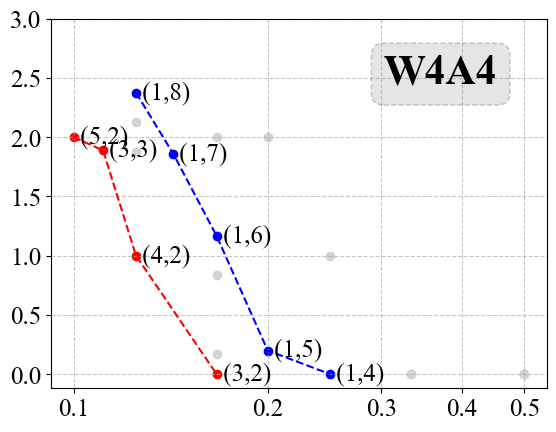

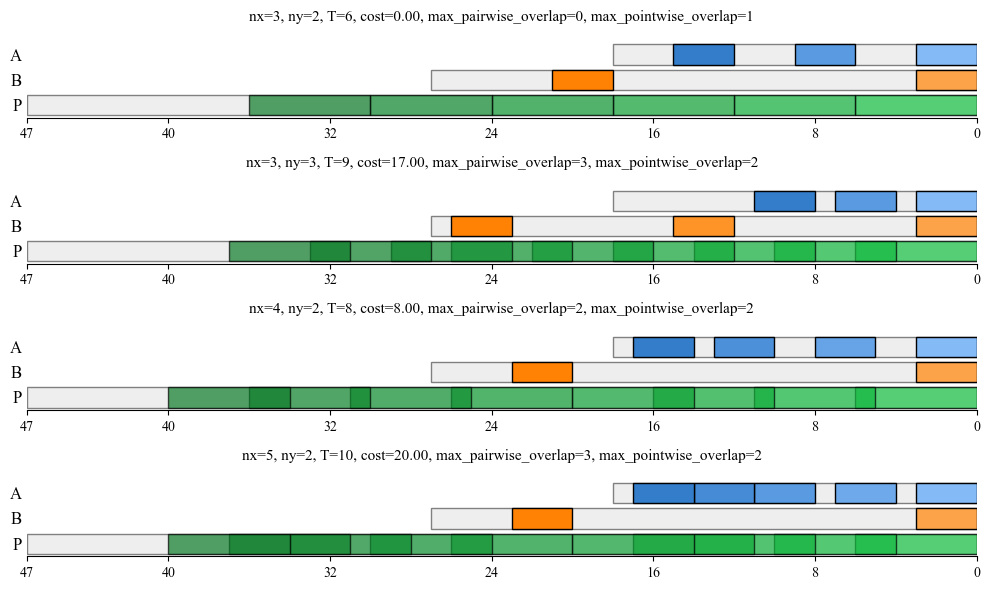

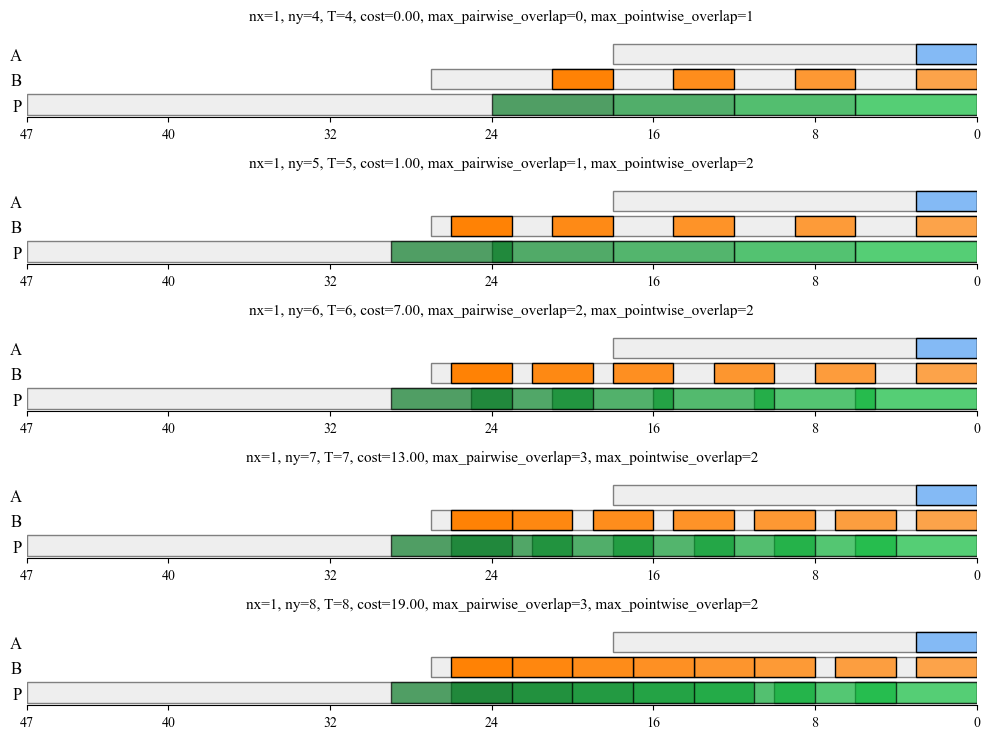

W4A4 Pareto max packing: 10


In [9]:
# Purpose: Evaluate a W4A4 layout and show its single-panel Pareto frontier.
# Evaluate a W4A4 layout and show its Pareto frontiers.
# print("DSP48E2")
w4a4_max = solve_and_draw(3,3, 17,26,47)
print(f"W4A4 Pareto max packing: {w4a4_max}")


INT3 x INT4


Uniform-model maximum packing: 12
INT3 x INT5


Uniform-model maximum packing: 12
INT4 x INT4
Uniform-model maximum packing: 10
INT4 x INT5
Uniform-model maximum packing: 8
INT5 x INT4


Uniform-model maximum packing: 8
INT5 x INT5
Uniform-model maximum packing: 6


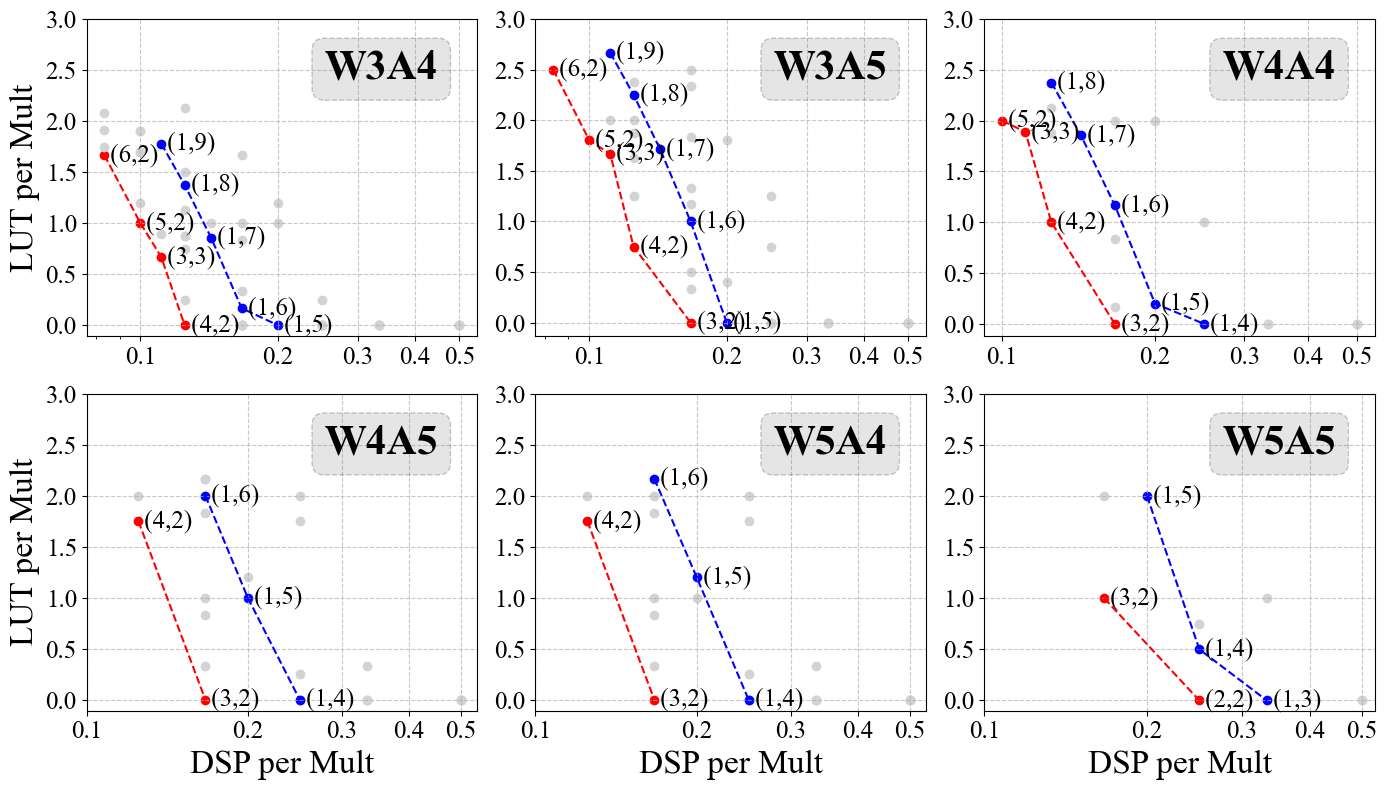

In [10]:
# Purpose: Render a 2x3 Pareto-frontier summary for the mixed-precision layout cases.
# The six panels reproduce the multi-precision Pareto view: W3A4, W3A5, W4A4, W4A5, W5A4, and W5A5.
pareto_layout_cases = [(3, 4), (3, 5), (4, 4), (4, 5), (5, 4), (5, 5)]
fig, axs = plt.subplots(2, 3, figsize=(14, 8))
axs = axs.flatten()

for panel_idx, (weight_bit, activation_bit) in enumerate(pareto_layout_cases):
    solve_and_draw(
        weight_bit - 1,
        activation_bit - 1,
        17,
        26,
        47,
        ax=axs[panel_idx],
        vis="none",
    )
    if panel_idx % 3 == 0:
        axs[panel_idx].set_ylabel("LUT per Mult", fontsize=24)
    if panel_idx >= 3:
        axs[panel_idx].set_xlabel("DSP per Mult", fontsize=24)

fig.tight_layout()
plt.show()
